<h1 style="font-size:30px;">Assignment: Implement a CNN for Image Classification</h1>

We started this module from linear regression, and gradually shifted our focus towards multi-class classification preferrably through CNNs.

In this notebook however, you would require to solve a binary classification problem using CNNs. We are using the popular Chihuahua-vs-Muffin dataset specifically for this task.

<center><img src="https://opencv.org/wp-content/uploads/2024/02/chihuahua-vs-muffin-feature-image.png" width=1000></center>

## <font style="color:rgb(50,120,230)">Marking scheme</font>

### Maximum Points: 30

<div>
    <table>
        <tr style="text-align: center;"><td><h3><strong>Section</strong></h3></td> <td><h3><strong>Problem</strong></h3></td> <td><h3><strong>Points</strong></h3></td></tr>
        <tr><td><h3>1</h3></td> <td><h3>Model Architecture</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>2</h3></td> <td><h3>Accuracy >=92%</h3></td> <td><h3>10</h3></td> </tr>
        <tr><td><h3>3</h3></td> <td><h3>Accuracy >=95%</h3></td> <td><h3>10</h3></td> </tr>
    </table>
</div>

## Problem Description

<hr style="border:none; height: 4px; background-color:#D3D3D3" />

### [<font style="color:rgb(50,120,230);text-decoration: underline">1. Implement the CNN Model</font>](#6-Model-Definition-[10-Points])

You are required to implement a CNN model from scratch. The feature extractor should contain atleast the **`Conv2d`**, **`BatchNorm2d`**, and **`ReLU`** layers.

Since we are solving a Binary Classification problem, we can use the **Binary Cross Entropy** loss intead of the usual **Cross Entropy Loss**. Hence, you need to ensure the correct `out_features` in the final **`Linear`** (FC) layer.

**You need to define the model architecture in the class: `BinaryClassifierModel`**. This section carries **`10`** points.

**Note:** For color images you need to use an input shape that has three channels, so that it accepts 3 channel inputs.


### [<font style="color:rgb(50,120,230);text-decoration: underline">2. Model Training and Accuracy</font>](#5-Configuration-[20-Points])

Once you have defined the model, you can train it. To get better accuracy, you need to experiment with the training configuration and even the model architecture. You can check the accuracy by running the training loop.

Here are a few hints on how you can improve the accuracy:
- Train for larger number of epochs
- Try using different learning rates
- Try to add more convolutional layers to the architecture
- Try to add more nodes in the layers.
- Experiment with the training image resolution.


You need to achieve atleast **92% accuracy** to obtain the remaining **`10`** points. To obtain the maximum grade for the assignment you need to achieve atleast **95% accuracy** for which you will be awarded the final **`10`** points.

**PS: Click on the headings above to jump to the respective sections in the notebook.**
<hr style="border:none; height: 4px; background-color:#D3D3D3" />

Since we have over `5000` samples across training and evaluation, building a model from scratch and training it requires significant time. **Leveraging compute resources such as GPUs can be beneficial for faster training.**

For ease of use, the assignment has been divided into two notebooks:

**Notebook 1 (Training)**: This is the training notebook (Colab), which you will use to train your binary classifier model.

You can execute this notebook in Google Colab or Kaggle Kernel to gain access to a GPU machine and prototype faster. Once the desired results are achieved, you should download the model checkpoints.

Access the Colab Notebook: [here](https://colab.research.google.com/drive/1TWchieUs1NqpvmH0X9GL3NhTQJlg5pbM)

**If you use Google Colab or any other compute engine (apart from Vocareum), kindly upload your model under a new folder named `CHECKPOINTS`.**

**Notebook 2 (Evaluation)**: This is the evaluation notebook (the one you are currently viewing in Labs), used to evaluate your model's accuracy. Upload your trained checkpoints and copy-paste the changes you made in the model definition section from Notebook 1. You will also need to update the mean and standard deviation values that you calculated in your training notebook in the `DatasetConfig` section.

> **Note:** Assignments are autograded based on specific **test cases** within individual graded sections. You should not delete any cells or modify the filename of this notebook for the Autograder to function correctly.

> You may only modify sections within  
> ```  
> ### BEGIN SOLUTION  
> ...  
> ### END SOLUTION  
> ```


<hr style="border:none; height: 4px; background-color:#D3D3D3" />




## Table of Contents

- [1 Import Dependencies](#1-Import-Dependencies)
- [2 System Config](#2-System-Config)
- [3 Preprocessing Transforms](#3-Preprocessing-Transforms)
- [4 Create Test Dataloader](#4-Create-Test-Dataloader)
- [5 Configuration](#5-Configuration-[20-Points])
- [6 Model Definition](#6-Model-Definition-[10-Points])
- [7 Evaluation Step](#7-Evaluation-Step)
- [8 Model Prediction on Test Data](#8-Model-Prediction-on-Test-Data)
- [9 Conclusion](#9-Conclusion)

## 1 Import Dependencies

In [1]:
import copy
from dataclasses import dataclass
import math
import numpy as np
import os
import random
import time
from typing import List, Union, Tuple
import warnings
from tqdm import tqdm
from IPython.display import clear_output

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

from torchvision.ops import Conv2dNormActivation
from torchvision import datasets, transforms as T
from torchinfo import summary

from torchmetrics import MeanMetric
from torchmetrics.classification import BinaryAccuracy

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import (MultipleLocator, FormatStrFormatter)

# To filter UserWarning.
warnings.filterwarnings("ignore", category=UserWarning)

bold = f"\033[1m"
reset = f"\033[0m"

/usr/local/lib/python3.10/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")


In [2]:
block_plot=False

## 2 System Config

In [3]:
def system_config(SEED_VALUE=42):
    """
    Configures the system environment for PyTorch-based operations.

    Args:
        SEED_VALUE (int): Seed value for random number generation. Default is 42.

    Returns:
        tuple: A tuple containing the device name as a string and a boolean indicating GPU availability.
    """

    random.seed(SEED_VALUE)
    np.random.seed(SEED_VALUE)
    torch.manual_seed(SEED_VALUE)

    print("Using CPU")
    DEVICE = torch.device("cpu")
    print("Device: ", DEVICE)
    GPU_AVAILABLE = False

    torch.use_deterministic_algorithms(True)

    return str(DEVICE), GPU_AVAILABLE

In [4]:
DEVICE, GPU_AVAILABLE = system_config()

Using CPU
Device:  cpu


## 3 Preprocessing Transforms

Before we forward pass the image data through the model, it needs to accept the data in batches as PyTorch tensors, pre-processed through a fixed image resolution. The following functions enables us to pre-process our data before it is passed through the CNN model.

* `image_preprocess_transforms()`: Resizes the image data into fixed image resolution, and converts PIL images to PyTorch tensors (and optionally scaling them if they are of `uint8` images).

* `get_common_transforms()`: The transformed images obtained from `image_preprocess_transforms` are then normalized using the appropriate mean and standard deviation.

### 3.1 Preporocess Transforms

In [5]:
def image_preprocess_transforms(img_size):

    preprocess = T.Compose([T.Resize((img_size[0], img_size[1]), antialias=True),
                            T.ToTensor()
                           ])
    return preprocess

### 3.2 Common Transforms

In [6]:
def get_common_transforms(resize_to, mean, std):

    preprocess = image_preprocess_transforms(img_size=resize_to)

    common_transforms = T.Compose([
        # Apply the usual pre-processing transforms.
        preprocess,

        # Normalize the image by subtracting the mean and dividing by the std dev. of the training dataset.
        T.Normalize(mean, std)
    ])

    return common_transforms

## 4 Create Test Dataloader

The `get_data` function is used to create the test dataloader.

In [7]:
def get_data(data_root, 
             img_size,
             batch_size,
             mean=(0.5,0.5,0.5),
             std=(0.5,0.5,0.5),
             shuffle_val_data=False,
             num_workers=1):

    test_data_path = os.path.join(data_root, "test")

    common_transforms = get_common_transforms(resize_to=img_size,
                                              mean=mean,
                                              std=std)


    # Shuffled Test Dataset.
    test_dataset = datasets.ImageFolder(root=test_data_path, transform=common_transforms)
    # Shuffle Indices.
    shuffled_idx = torch.randperm(len(test_dataset))
    # Get shuffled dataset
    test_dataset_shuffled = Subset(test_dataset, indices=shuffled_idx)
    # Test DataLoader.
    test_loader = DataLoader(test_dataset_shuffled,
                             batch_size=batch_size,
                             shuffle=shuffle_val_data,
                             num_workers=num_workers
                            )

    return test_loader

## 5 Configuration [20 Points]

All training parameters are defined here. So, this is where you can improve your accuracy, apart from improving the architecture.

Here are a few hints on how you can improve the accuracy:
- Train for a larger number of epochs
- Try different learning rates
- Try with different image resolution

**You need to achieve atleast 92% accuracy on this given data to obtain atleast 10 points. To obtain the complete 20 points, you need to achieve atleast 95% for this assignment.**

<font style="color:red;font-size:15px"><b>Note:</b> You need to copy-paste the mean and std of the training data that was used during training.<br>Also ensure that you are using the same <b>image resolution</b> used during training.</font>

A sample snapshot is shown below.<br><br>
<img src="https://opencv.org/wp-content/uploads/2024/02/cnn-assignment-mean-std.png" width=700>

In [8]:
@dataclass(frozen=True)
class DatasetConfig:
    BATCH_SIZE:  int = 8 # Please don't change the batch size here.
    IMG_HEIGHT:  int = 224
    IMG_WIDTH:   int = 224
    MEAN:      tuple = (0.5, 0.5, 0.5) # Pass the computed mean and std from the training notebook
    STD:       tuple = (0.5, 0.5, 0.5)
    NUM_WORKERS: int = 4
    DATA_ROOT:   str = "../data/data-muffin-vs-chihuahua"
    
    # You are entitled to modify the above parameters except NUM_WORKERS, DATA_ROOT.
    ###
    ### YOUR CODE HERE
    MEAN:      tuple = (0.6501, 0.5935, 0.5400)
    STD:       tuple = (0.2951, 0.3002, 0.3204)
    ###

@dataclass(frozen=True)
class TrainingConfig:
    EPOCHS:          int  = 5
    LEARNING_RATE:  float = 1e-2
    MOMENTUM:       float = 0.9
    DEVICE:         str = "cpu"
    CHECKPOINT_DIR: str = "CHECKPOINTS"
    MODEL_FILENAME: str = "Model_best_acc.pth"

    # You can modify the above parameters except CHECKPOINT_DIR and MODEL_FILENAME.
    ###
    ### YOUR CODE HERE
    ###


Let us now initialize the parameters defined above.

In [9]:
train_config = TrainingConfig()
dataset_config = DatasetConfig()

## 6 Model Definition [10 Points]

You need to write the model architecture here.

**Note:**

1. Since we will be using **Binary Cross Entropy** as the loss function, you need to ensure the correct `out_features` for the final fully connected (linear) layer.
2. You need to make sure that the model parameters are not too high. We were able to achieve well over **96.5%** test accuracy with the number of parameters as low as **1.7M**.

Here are a few pointers that you can implement in case you don't get the desired accuracy:
1. Try adding more convolution layers to the backbone.
2. Experiment with the kernel size in the Convolution layers.
3. Try adding an Adaptive Average Pooling Layer as the final layer in the backbone.
4. Try increasing the filters/nodes in the Conv/Linear layers.

In [10]:
class BinaryClassifierModel(nn.Module):
    def __init__(self):
        
        super().__init__()
        
        self.conv_block_0 = nn.Sequential(nn.Conv2d(3, 64, 7, padding=3, stride=2, bias=False),
                                          nn.BatchNorm2d(64),
                                          nn.ReLU(inplace=True),
                                          nn.MaxPool2d(2,2)
                                         )
        
        ### Residual Block 1 (3x3) - No reduction required
        self.shortcut_1 = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1, bias=False),
                                       nn.BatchNorm2d(64)
                                       )
        
        self.residual_block_1_0 = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1, bias=False),
                                               nn.BatchNorm2d(64),
                                               nn.ReLU(inplace=True),
                                               nn.Conv2d(64, 64, 3, padding=1, bias=False),
                                               nn.BatchNorm2d(64)
                                               )
        self.residual_block_1_1 = nn.Sequential(nn.Conv2d(64, 64, 3, padding=1, bias=False),
                                                nn.BatchNorm2d(64),
                                                nn.ReLU(inplace=True),
                                               # nn.Conv2d(64,64,3,padding=1, bias=False),
                                               # nn.BatchNorm2d(64),
                                                nn.Dropout2d(0.003)
                                               )
        
        ###Residual Block 2 Reduction required in first Conv2D in first block component
        self.shortcut_3 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1, stride=2, bias=False),
                                        nn.BatchNorm2d(128)
                                        )
        
        self.residual_block_2_0 = nn.Sequential(nn.Conv2d(64, 128, 3, padding=1, stride=2, bias=False),
                                                nn.BatchNorm2d(128),
                                                nn.ReLU(inplace=True),
                                                #nn.Conv2d(128, 128,3, padding=1, bias=False),
                                                #nn.BatchNorm2d(128)
                                               )
        self.residual_block_2_1 = nn.Sequential(nn.Conv2d(128, 128, 3, padding=1, bias=False),
                                                nn.BatchNorm2d(128),
                                                nn.ReLU(inplace=True),
                                               # nn.Conv2d(128, 128,3, padding=1, bias=False),
                                                #nn.BatchNorm2d(128),
                                                nn.Dropout2d(0.003)
                                               )
        
        
        ###Residual Block 3 Reduction required in first Conv2D in first block component
        
        self.shortcut_5 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1, stride=2, bias=False),
                                        nn.BatchNorm2d(256)
                                       )
        self.residual_block_3_0 = nn.Sequential(nn.Conv2d(128, 256, 3, padding=1, stride=2, bias=False),
                                                nn.BatchNorm2d(256),
                                                nn.ReLU(inplace=True),
                                                #nn.Conv2d(256, 256,3, padding=1, bias=False),
                                                #nn.BatchNorm2d(256)
                                               )

        self.residual_block_3_1 = nn.Sequential(nn.Conv2d(256, 256, 3, padding=1, bias=False),
                                                nn.BatchNorm2d(256),
                                                nn.ReLU(inplace=True),
                                                #nn.Conv2d(256, 256,3, padding=1, bias=False),
                                                #nn.BatchNorm2d(256),
                                                nn.Dropout2d(0.003)
                                               )
        ##Residual Block 4 Reduction required in first Conv2D in first block component
        
        self.shortcut_7 = nn.Sequential(nn.Conv2d(256, 512, 3, padding=1, stride=2, bias=False),
                                        nn.BatchNorm2d(512)
                                       )
        
        self.residual_block_4_0 = nn.Sequential(nn.Conv2d(256, 512, 3, padding=1, stride=2, bias=False),
                                                nn.BatchNorm2d(512),
                                                nn.ReLU(inplace=True),
                                                #nn.Conv2d(512, 512,3, padding=1, bias=False),
                                                #nn.BatchNorm2d(512)
                                               )
        self.residual_block_4_1 = nn.Sequential(nn.Conv2d(512, 512, 3, padding=1, bias=False),
                                                nn.BatchNorm2d(512),
                                                nn.ReLU(inplace=True),
                                                #nn.Conv2d(512, 512,3, padding=1, bias=False),
                                                #nn.BatchNorm2d(512),
                                                nn.Dropout2d(0.003)
                                               )
        self.aggregate = nn.AdaptiveAvgPool2d((1,1))
        
        self.classifier = nn.Sequential(nn.Flatten(),
                                        nn.Linear(512, 64, bias=False),
                                        nn.BatchNorm1d(64),
                                        nn.ReLU(inplace=True),
                                        nn.Dropout(0.3),
                                        nn.Linear(64, 1)
                                       )
        
    def forward(self, x):
        x = self.conv_block_0(x)
        
        x_shortcut_1 = self.shortcut_1(x)
        x = self.residual_block_1_0(x)
        x = x + x_shortcut_1
        x = nn.ReLU(inplace=True)(x)
        
        x_shortcut_2 = x
        x = self.residual_block_1_1(x)
        x = x + x_shortcut_2
        x = nn.ReLU(inplace=True)(x)
        #print(x.shape)
        
        x_shortcut_3 = self.shortcut_3(x)
        x = self.residual_block_2_0(x)
        x = x + x_shortcut_3
        x = nn.ReLU(inplace=True)(x)
        #print(x.shape)
        
        x_shortcut_4 = x
        x = self.residual_block_2_1(x)
        x = x + x_shortcut_4
        x =  nn.ReLU(inplace=True)(x)
        
        x_shortcut_5 = self.shortcut_5(x)
        x = self.residual_block_3_0(x)
        x = x + x_shortcut_5
        x = nn.ReLU(inplace=True)(x)
        #print(x.shape)
        
        x_shortcut_6 = x
        x = self.residual_block_3_1(x)
        x = x + x_shortcut_6
        x = nn.ReLU(inplace=True)(x)
        
        x_shortcut_7 = self.shortcut_7(x)
        x = self.residual_block_4_0(x)
        x = x + x_shortcut_7
        x = nn.ReLU(inplace=True)(x)
        #print(x.shape) 
        
        x_shortcut_8 = x
        x = self.residual_block_4_1(x)
        x = x + x_shortcut_8
        x = nn.ReLU(inplace=True)(x)
        
        x = self.aggregate(x)
        x = self.classifier(x)
        return x

Let us now print the model summary.

In [11]:
model = BinaryClassifierModel()

print(summary(model,
              input_size=(1, 3, dataset_config.IMG_HEIGHT, dataset_config.IMG_WIDTH),
              device="cpu",
              row_settings=["var_names"]))

Layer (type (var_name))                            Output Shape              Param #
BinaryClassifierModel (BinaryClassifierModel)      [1, 1]                    --
├─Sequential (conv_block_0)                        [1, 64, 56, 56]           --
│    └─Conv2d (0)                                  [1, 64, 112, 112]         9,408
│    └─BatchNorm2d (1)                             [1, 64, 112, 112]         128
│    └─ReLU (2)                                    [1, 64, 112, 112]         --
│    └─MaxPool2d (3)                               [1, 64, 56, 56]           --
├─Sequential (shortcut_1)                          [1, 64, 56, 56]           --
│    └─Conv2d (0)                                  [1, 64, 56, 56]           36,864
│    └─BatchNorm2d (1)                             [1, 64, 56, 56]           128
├─Sequential (residual_block_1_0)                  [1, 64, 56, 56]           --
│    └─Conv2d (0)                                  [1, 64, 56, 56]           36,864
│    └─BatchNorm2d (1)

In [12]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


In [13]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


In [14]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


In [15]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


## 7 Evaluation Step

In [16]:
def evaluate(
    train_config: TrainingConfig,
    model: nn.Module,
    test_loader: torch.utils.data.DataLoader,
) -> Tuple[float, float]:

    # Model in eval() mode
    model.eval()

    acc_metric = BinaryAccuracy()
    mean_metric = MeanMetric()

    total_steps = len(test_loader)


#     prog_bar = tqdm(test_loader, bar_format='{l_bar}{bar:10}{r_bar}{bar:-10b}')
    
    begin_t = time.time()

    for idx, (data, targets) in enumerate(test_loader,1):
        
        clear_output(wait=True)

        # Send data and target to the appropriate device.
        batch_data = data.to(train_config.DEVICE)
        batch_targets = targets.float().to(train_config.DEVICE)

        # Get the model's predicted logits.
        with torch.no_grad():
            logits = model(batch_data).squeeze(dim=-1)

        # Compute the CE-Loss.
        test_loss = F.binary_cross_entropy_with_logits(logits, batch_targets).item()

        # Get the batch predictions after converting them to probability scores.
        pred_idx = torch.round(logits.sigmoid())

        # Batch validation loss.
        batch_loss = mean_metric(test_loss, weight=data.shape[0])

        # Batch validation accuracy.
        _ = acc_metric(pred_idx.cpu(), targets)

        # Update progress bar description.
        step_status = f"Step: {bold}{idx}/{total_steps}{reset}"
        step_status+= f" Loss: {mean_metric.compute():.4f}, Acc: {acc_metric.compute():.4f}"
        print(step_status)
        


    test_loss = mean_metric.compute()
    test_acc = acc_metric.compute()
    
    print(f"Test Loss: {test_loss:.3f}\tTest Acuracy: {test_acc:.2f}")
    
    print(f"\nTotal time taken: {(time.time()-begin_t):.2f}s")


    return test_loss, test_acc

In [17]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


In [18]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


## 8 Model Prediction on Test Data

### 8.1 Load Model

In [19]:
def load_model_from_checkpoint(ckpt_dir = TrainingConfig.CHECKPOINT_DIR,
                               model_filename = TrainingConfig.MODEL_FILENAME,
                               device = TrainingConfig.DEVICE):

    model_path = os.path.join(ckpt_dir, model_filename)
    model = BinaryClassifierModel()
    model.load_state_dict(torch.load(model_path, map_location=TrainingConfig.DEVICE))

    model = model.to(device)

    return model

### 8.2 Data Denormalization

Recall that the image data being forward propagated through the model is in normalized form. For visualization purpose, we need to de-normalize this image data. The denormalize function exactly does that.

In [20]:
def denormalize(img_tensor,
                mean = torch.tensor([0.5, 0.5, 0.5]),
                std = torch.tensor([0.5, 0.5, 0.5])):

    denorm_image = (img_tensor * std[:,None,None] + mean[:,None,None]).clamp(min=0., max=1.)

    return denorm_image

### 8.3 Perform Batch Prediction

In [21]:
def batch_prediction(model, image_batch, device="cpu"):

    # run model in evaluation mode.
    model.eval()

    with torch.no_grad():
        output_logits = model(image_batch.to(device)).squeeze(dim=-1)

    # Get probability score using softmax
    batch_probs = output_logits.sigmoid()

    # Get the predicted class IDs
    pred_cls_batch = torch.round(batch_probs)

    # Get masks for prob < 0.5 => Class = 0.
    masks = batch_probs < 0.5

    # Update prob for Class 0 to 1. prob
    batch_probs[masks] = 1.- batch_probs[masks]

    # Convert predictions to lists
    pred_cls_batch = pred_cls_batch.cpu().int().tolist()
    pred_prob_batch = batch_probs.cpu().tolist()

    return pred_cls_batch, pred_prob_batch

### 8.4 Plot Model Predictions

In [22]:
def sample_prediction(data_loader, model, device="cpu"):

    class_to_idx = data_loader.dataset.dataset.class_to_idx
    idx_to_class = {v:k for k,v in class_to_idx.items()}

    # get val_dataloader for data_module.
    val_data_batch = next(iter(data_loader))

    # Image batch
    image_batch = val_data_batch[0]

    # GT batch.
    target_batch = val_data_batch[1]

    pred_cls_batch, pred_prob_batch = batch_prediction(model, image_batch, device)

    denorm_imgs = []
    denorm_imgs.extend([np.asarray(T.functional.to_pil_image(image)) for image in denormalize(image_batch)])


    plt.figure(figsize=(16, 8))

    for idx, (img, true, pred, prob) in enumerate(zip(denorm_imgs, target_batch, pred_cls_batch, pred_prob_batch), 1):

        ax = plt.subplot(2, 4, idx)
        plt.imshow(img)
        title = f"GT:{idx_to_class[int(true)]}, Pred:{idx_to_class[pred]}({prob:.1f})"
        title_obj = plt.title(title)

        if pred == true:
            plt.setp(title_obj, color="g")
        else:
            plt.setp(title_obj, color="r")
        plt.axis("off")

    plt.show()

    return

In [23]:
test_loader = get_data(data_root=dataset_config.DATA_ROOT,
                       img_size=(dataset_config.IMG_HEIGHT,
                                 dataset_config.IMG_WIDTH),
                       batch_size=dataset_config.BATCH_SIZE,
                       mean=dataset_config.MEAN,
                       std=dataset_config.STD,
                       num_workers=2)

# Load Trained Model.
trained_model = load_model_from_checkpoint()

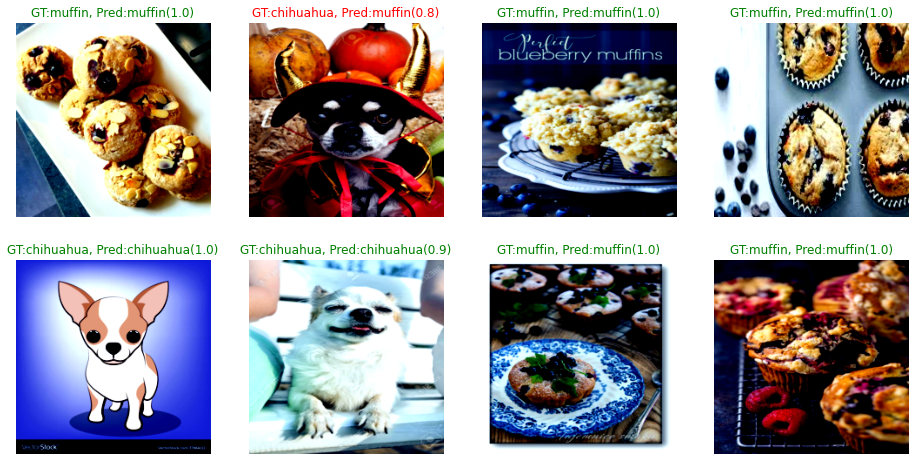

In [24]:
# Load Trained Model.
trained_model = load_model_from_checkpoint()
sample_prediction(test_loader, trained_model, train_config.DEVICE)

## 9 Conclusion

We train a binary classification model on a dataset consisting of chihuahuas and muffins. The distribution between these classes is similar, making training challenging. Although we have tried to achieve 95% test accuracy, we can improve it further. List down your findings on the significant changes you have implemented that helped your model achieve beyond 95%  test accuracy.